# Progetto di Linguistica Computazionale II - Matilde Viti
# Task 4: 
## Esperimento 2: Selezione del best model

Il modello viene addestrato per 6 epoche, ma il checkpoint finale viene selezionato automaticamente sulla base delle prestazioni sul validation set. In questo caso, il modello migliore corrisponde alla seconda epoca.

In [1]:
!pip install --upgrade datasets
!pip install evaluate
!pip install transformers
#!pip install accelerate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 526.6/526.6 kB 23.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.6/47.6 MB 23.3 MB/s eta 0:00:00
  Attempting uninstall: pyarrow
    Found existing installation: pyarrow 18.1.0
    Uninstalling pyarrow-18.1.0:
      Successfully uninstalled pyarrow-18.1.0
  Attempting uninstall: datasets
    Found existing installation: datasets 4.0.0
    Uninstalling datasets-4.0.0:
      Successfully uninstalled datasets-4.0.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 5.4 MB/s eta 0:00:00


In [2]:
import os
from google.colab import drive

import numpy as np
import pandas as pd

import datasets
import evaluate
import seaborn as sns

# Libreria transformers per utilizzare i Transformer models
from transformers import AutoTokenizer
from transformers import AutoModelForSequenceClassification, TrainingArguments, Trainer

# Librerie per le metriche
from sklearn.metrics import classification_report
from sklearn.metrics import ConfusionMatrixDisplay
import json

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
data_folder = "/content/drive/MyDrive/profiling_input/profiling_input"
info_path = "/content/drive/MyDrive/profiling_input/json/paragraph_info.json"

with open(info_path, "r", encoding="utf-8") as f:
    paragraph_info = json.load(f)

documents = os.listdir(data_folder)

train_data = []
validation_data = []
test_data = []
labels = []

for document in documents:
    if not document.endswith(".txt"):
        continue


    # ID = nome file senza .txt
    paragraph_id = document.replace(".txt", "")

    # recupero info dal JSON
    info = paragraph_info[paragraph_id]
    label = info["author"]
    split = info["split"]

    if label not in labels:
        labels.append(label)

    with open(os.path.join(data_folder, document), "r", encoding="utf-8") as f:
        text = f.read()

    input_instance = {
        "doc_id": paragraph_id,
        "text": text,
        "label": label,
        "split": split
    }

    if split == "train":
        train_data.append(input_instance)
    elif split == "validation":
        validation_data.append(input_instance)
    elif split == "test":
        test_data.append(input_instance)

labels = sorted(labels)
str_to_int = {label: num for num, label in enumerate(labels)}

print("Train:", len(train_data))
print("Validation:", len(validation_data))
print("Test:", len(test_data))
print("Labels:", labels)

Train: 4312
Validation: 600
Test: 594
Labels: ['Charlotte Bronte', 'George Eliot', 'Jane Austen']


Pre-processing dei dati

In [5]:
train = datasets.Dataset.from_pandas(pd.DataFrame(data=train_data))
test = datasets.Dataset.from_pandas(pd.DataFrame(data=test_data))
validation = datasets.Dataset.from_pandas(pd.DataFrame(data=validation_data))

In [6]:
print("Train:", train.shape)
print("Validation:", validation.shape)
print("Test:", test.shape)

Train: (4312, 4)
Validation: (600, 4)
Test: (594, 4)


In [7]:
print(train.features)

{'doc_id': Value('string'), 'text': Value('string'), 'label': Value('string'), 'split': Value('string')}


In [9]:
from transformers import DistilBertTokenizer, DistilBertForSequenceClassification
model_name = "distilbert-base-cased"
tokenizer = DistilBertTokenizer.from_pretrained(model_name)
model = DistilBertForSequenceClassification.from_pretrained(model_name, num_labels=len(labels), problem_type="single_label_classification")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/465 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/263M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-cased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


# Tokenizzazione dei dati

In [10]:
# Funzione che applica la tokenizzazione ai dati di training, val e test
def tokenize(batch):
    tokens = tokenizer(batch['text'], padding="max_length", truncation=True, max_length=512)
    tokens['label'] = [str_to_int[label] for label in batch["label"]]

    return tokens

train = train.map(tokenize, batched=True)
validation = validation.map(tokenize, batched=True)
test = test.map(tokenize, batched=True)


print(train.features, validation.features, test.features)


Map:   0%|          | 0/4312 [00:00<?, ? examples/s]

Map:   0%|          | 0/600 [00:00<?, ? examples/s]

Map:   0%|          | 0/594 [00:00<?, ? examples/s]

{'doc_id': Value('string'), 'text': Value('string'), 'label': Value('int64'), 'split': Value('string'), 'input_ids': List(Value('int32')), 'attention_mask': List(Value('int8'))} {'doc_id': Value('string'), 'text': Value('string'), 'label': Value('int64'), 'split': Value('string'), 'input_ids': List(Value('int32')), 'attention_mask': List(Value('int8'))} {'doc_id': Value('string'), 'text': Value('string'), 'label': Value('int64'), 'split': Value('string'), 'input_ids': List(Value('int32')), 'attention_mask': List(Value('int8'))}


In [11]:
## ERRORE DI NUMPY:
# The error indicates that the loss function is receiving floating-point labels
#instead of integer labels on the GPU. This is likely due to how the data is being
#formatted before training. We need to explicitly set
#the dataset format to 'torch' to ensure the labels are passed as long integers to the PyTorch model. I will update the relevant cell to reflect this change.

train.set_format('torch', columns=['input_ids', 'attention_mask', 'label'])
validation.set_format('torch', columns=['input_ids', 'attention_mask', 'label'])
test.set_format('torch', columns=['input_ids', 'attention_mask', 'label'])

# Addestramento modello

In [13]:
num_epochs = 6

training_args = TrainingArguments(
    output_dir=f"{model_name}-finetuned",
    eval_strategy="epoch",
    logging_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=1,
    learning_rate=5e-6,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=num_epochs,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
)

In [14]:
def compute_metrics(eval_pred):
  f1_metric = evaluate.load("f1")
  predictions, labels = eval_pred
  predictions = np.argmax(predictions, axis=1)

  return f1_metric.compute(predictions=predictions, references=labels, average="weighted")

In [15]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train,
    eval_dataset=validation,
    #tokenizer=tokenizer,
    compute_metrics=compute_metrics
)

trainer.train()
trainer.save_model("/content/drive/My Drive/FINETUNED_BESTMODEL")

Epoch,Training Loss,Validation Loss,F1
1,0.604732,0.568392,0.794691
2,0.193376,0.629077,0.831115
3,0.119583,0.887047,0.803742
4,0.067880,0.949167,0.824958
5,0.058663,1.006840,0.823238
6,0.040508,1.065395,0.817433


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

# Curve di loss

/tmp/ipykernel_3012/3703003683.py:12: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, log_df], ignore_index=True)


<Axes: xlabel='Epoch', ylabel='Loss'>

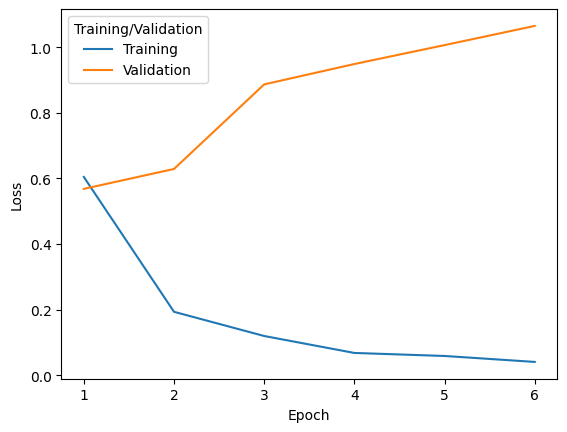

In [16]:
log_history = trainer.state.log_history

# Creo dataframe pandas per memorizzare le loss di training/evaluation e poi mostrare graficamente le curve
df = pd.DataFrame(columns=["Epoch", "Loss", "Training/Validation"])

for log_data in log_history:
  epoch = int(log_data["epoch"])
  if "loss" in log_data.keys():
    loss = log_data["loss"]

    log_df = pd.DataFrame({"Epoch": [epoch], "Loss": [loss], "Training/Validation": ["Training"]})
    df = pd.concat([df, log_df], ignore_index=True)
  if "eval_loss" in log_data.keys():
    loss = log_data["eval_loss"]
    log_df = pd.DataFrame({"Epoch": [epoch], "Loss": [loss], "Training/Validation": ["Validation"]})
    df = pd.concat([df, log_df], ignore_index=True)

# Lineplot della loss
sns.lineplot(data=df, x="Epoch", y="Loss", hue="Training/Validation")

# Performance sul test set

In [17]:
output_predictions = trainer.predict(test)

Classification Report:
                  precision    recall  f1-score   support

Charlotte Bronte       0.91      0.65      0.76       194
    George Eliot       0.85      0.90      0.88       200
     Jane Austen       0.76      0.93      0.84       200

        accuracy                           0.83       594
       macro avg       0.84      0.83      0.82       594
    weighted avg       0.84      0.83      0.82       594


Confusion Matrix: <sklearn.metrics._plot.confusion_matrix.ConfusionMatrixDisplay object at 0x7af71531f3b0>


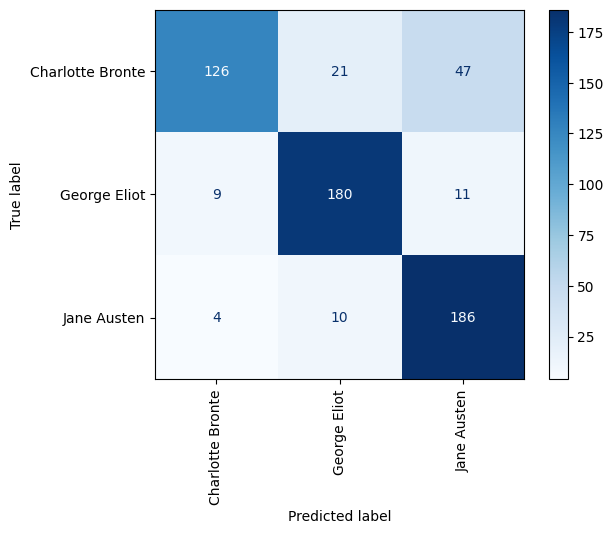

In [18]:
y_test = test["label"]
y_pred = np.argmax(output_predictions.predictions, axis=1)

report = classification_report(y_test, y_pred, target_names=labels)
cm = ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=labels,
    xticks_rotation="vertical",
    cmap="Blues"
)

print("Classification Report:")
print(report)
print(f"\nConfusion Matrix: {cm}")

In [19]:
trainer.state.best_model_checkpoint

'distilbert-base-cased-finetuned/checkpoint-1078'

In [20]:
trainer.state.best_metric

0.831114590819474

In [21]:
steps_per_epoch = len(train) // 8
print(steps_per_epoch)

539


In [22]:
1078 / steps_per_epoch

2.0